In [ ]:
import subprocess
import sys

# Relaxed constraints to allow Python 3.12 compatible versions
packages = [
    'numpy>=1.26.0', # Numpy 1.26+ is required for Python 3.12
    'pandas>=2.1.0',
    'matplotlib>=3.8.0',
    'seaborn>=0.13.0',
    # Torch often lags behind on newest Python versions.
    # If the line below fails, try removing the version constraints specific to torch.
    'torch>=2.1.0',
    'tqdm>=4.66.0',
]

print(f"Installing packages into: {sys.executable}")

for package in packages:
    try:
        print(f"Installing {package}...")
        # Removed '-q' so we can see installation progress and errors if they happen
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])
    except subprocess.CalledProcessError as e:
        print(f"\nCRITICAL ERROR installing {package}.")
        print("See the output above for details.")
        sys.exit(1)

print("\n✓ All packages installed successfully")

Installing packages into: /usr/bin/python3
Installing numpy>=1.26.0...
Installing pandas>=2.1.0...
Installing matplotlib>=3.8.0...
Installing seaborn>=0.13.0...
Installing torch>=2.1.0...
Installing tqdm>=4.66.0...

✓ All packages installed successfully


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import logging
from dataclasses import dataclass, field
from typing import List, Dict, Optional
from abc import ABC, abstractmethod
import torch
import torch.nn as nn
import torch.optim as optim
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ All imports successful")

✓ All imports successful


In [ ]:
@dataclass
class ChargingStation:
    id: str
    country: str
    city: str
    latitude: float
    longitude: float
    network: str
    connectors: str
    max_power_kw: float
    cost_per_kwh_usd: float
    status: str
    install_year: int
    is_24_7: bool
    accessibility: str

@dataclass
class Query:
    query_id: str
    user_latitude: float
    user_longitude: float
    min_power_kw: float = 50.0
    max_distance_km: float = 15.0
    max_price_usd_per_kwh: Optional[float] = None
    prefer_availability: bool = True
    timestamp: Optional[int] = None

@dataclass
class AlgorithmMetrics:
    algorithm_name: str
    budget: int
    relevance: float
    cost_savings: float
    power_adequacy: float
    constraint_violations: float
    transparency: float
    regret: float
    time_per_query_ms: float

print("✓ Data structures defined")

✓ Data structures defined


In [ ]:
import kagglehub
path = kagglehub.dataset_download("zsarpong/1-5m-global-ev-charging-stations")

Using Colab cache for faster access to the '1-5m-global-ev-charging-stations' dataset.


In [ ]:
import kagglehub
path = kagglehub.dataset_download("likithagedipudi/ev-charging-station-availability-tracking")

In [ ]:
import inspect, time
import numpy as np
import pandas as pd

def haversine_distance_vec(lat1, lon1, lat2, lon2):
    """Vectorized haversine distance in km."""
    R = 6371.0
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def run_static_benchmark_correct(
    static_df,
    budgets=[100, 1000, 10000, 100000],     # don’t put 1e6 unless you truly run it
    n_seeds=5,
    candidate_k=50,
    max_steps_cap=None                       # set e.g. 20000 if runtime too big
):
    """
    Correct static benchmark on REAL dataset:
    - candidates sampled NEAR query (fix infeasibility/reward flatness)
    - power adequacy is binary
    - constraint violations are correctly defined
    - regret computed vs oracle per step
    """
    # ---- Required columns ----
    needed = ["latitude","longitude","max_power_kw","cost_per_kwh_usd","status"]
    for c in needed:
        if c not in static_df.columns:
            raise ValueError(f"Missing column: {c}")

    # ---- Clean status to consistent values ----
    df = static_df.copy()
    df["status"] = df["status"].astype(str).str.lower()

    # ---- ChargingStation safe constructor ----
    station_sig = inspect.signature(ChargingStation)
    valid_station_keys = set(station_sig.parameters.keys())

    def create_station_safe(row_dict):
        clean_dict = {k: row_dict[k] for k in row_dict.keys() if k in valid_station_keys}
        return ChargingStation(**clean_dict)

    # ---- Algorithms (ONLY real ones) ----
    algorithms = {
        "LinUCB": lambda: LinUCB(8),
        "Thompson": lambda: ThompsonSampling(8),
        "NeuralBandit": lambda: NeuralBandit(8, hidden_dim=32),
        "DQN": lambda: DQN(8),
        # If PPO exists and is stable in your setup, add it:
        # "PPO": lambda: PPO(8),
    }

    results = []

    for seed in range(n_seeds):
        np.random.seed(seed)

        for budget in budgets:
            steps = budget if max_steps_cap is None else min(budget, max_steps_cap)

            for algo_name, algo_factory in algorithms.items():
                policy = algo_factory()

                rewards = []
                regrets = []
                viols = []
                power_ok = []
                cost_savings = []
                times_ms = []

                for t in range(steps):
                    # ---- sample query anchor from dataset ----
                    idx = np.random.randint(len(df))
                    base = df.iloc[idx]

                    q = Query(
                        query_id=f"q_{seed}_{algo_name}_{budget}_{t}",
                        user_latitude=float(base["latitude"]) + np.random.randn() * 0.02,
                        user_longitude=float(base["longitude"]) + np.random.randn() * 0.02,
                        min_power_kw=float(np.random.choice([50,100,150])),
                        max_distance_km=15.0,
                        max_price_usd_per_kwh=0.35,
                    )

                    # ---- Candidate selection: pick nearest stations (IMPORTANT FIX) ----
                    # This avoids “all infeasible” and makes reward vary.
                    dists = haversine_distance_vec(
                        q.user_latitude, q.user_longitude,
                        df["latitude"].values, df["longitude"].values
                    )
                    # choose nearest candidate_k
                    near_idx = np.argpartition(dists, candidate_k)[:candidate_k]
                    candidates_df = df.iloc[near_idx].copy()
                    candidates_df["dist_km"] = dists[near_idx]

                    # build station objects
                    station_objects = [create_station_safe(r.to_dict()) for _, r in candidates_df.iterrows()]

                    # ---- Build features ----
                    X = np.array([feature_builder.build(q, s) for s in station_objects], dtype=float)

                    # ---- Select action ----
                    t0 = time.time()
                    a = policy.select(X, list(range(len(station_objects))))
                    if a < 0 or a >= len(station_objects):
                        a = int(np.random.randint(len(station_objects)))
                    times_ms.append((time.time() - t0) * 1000.0)

                    chosen = station_objects[a]

                    # ---- Compute reward for ALL candidates (oracle regret) ----
                    cand_rewards = []
                    cand_feasible = []
                    cand_prices = []

                    for i, st in enumerate(station_objects):
                        price_i = float(getattr(st, "cost_per_kwh_usd", 0.25))
                        status_i = str(getattr(st, "status", "operational")).lower()

                        r_i, feasible_i, _ = reward_fn.compute(q, st, price=price_i, status=status_i)
                        cand_rewards.append(float(r_i))
                        cand_feasible.append(bool(feasible_i))
                        cand_prices.append(price_i)

                    # chosen reward
                    chosen_price = float(getattr(chosen, "cost_per_kwh_usd", 0.25))
                    chosen_status = str(getattr(chosen, "status", "operational")).lower()
                    r, feasible, _ = reward_fn.compute(q, chosen, price=chosen_price, status=chosen_status)

                    # update
                    policy.update(X, a, float(r))

                    # ---- metrics (correct definitions) ----
                    rewards.append(float(r))

                    # violation: 1 if infeasible else 0
                    viol = 1 if not feasible else 0
                    viols.append(viol)

                    # power adequacy: 1 if meets min_power else 0
                    p_ok = 1 if float(getattr(chosen, "max_power_kw", 0.0)) >= q.min_power_kw else 0
                    power_ok.append(p_ok)

                    # cost savings: min feasible price - chosen price (>=0 is good)
                    feasible_prices = [p for p,f in zip(cand_prices, cand_feasible) if f]
                    min_price = min(feasible_prices) if feasible_prices else chosen_price
                    cost_savings.append(max(0.0, min_price - chosen_price))

                    # regret vs oracle: best feasible reward - chosen reward
                    feasible_rewards = [cr for cr, f in zip(cand_rewards, cand_feasible) if f]
                    oracle = max(feasible_rewards) if feasible_rewards else float(r)
                    regrets.append(max(0.0, oracle - float(r)))

                # ---- aggregate ----
                results.append({
                    "Budget": budget,
                    "Steps_run": steps,
                    "Algorithm": algo_name,

                    # Relevance: mean reward (should vary now)
                    "Relevance ↑": float(np.mean(rewards)),

                    "Cost savings ↑": float(np.mean(cost_savings)),
                    "Power adequacy ↑": float(np.mean(power_ok)),  # (0–1)

                    "Constraint violations ↓": float(np.mean(viols)),  # (0–1)

                    "Cumulative regret ↓": float(np.sum(regrets)),
                    "Time/query (ms) ↓": float(np.mean(times_ms)),
                })

    return pd.DataFrame(results)



table1_df = run_static_benchmark_correct(
    static_df=cleaned_df,
    budgets=[100, 1000, 10000],   # start here; only go higher when stable
    n_seeds=5,
    candidate_k=50,
    max_steps_cap=None            # if slow, set to 20000 and DO NOT claim bigger budgets
)

table1_df


Original Columns: ['id', 'country', 'city', 'network', 'latitude', 'longitude', 'connectors_available', 'connector_types', 'power_level', 'max_power_kw']
Mapped Columns: ['id', 'country', 'city', 'network', 'latitude', 'longitude', 'connectors', 'connector_types', 'power_level', 'max_power_kw']

Retrying benchmark with mapped data...
Starting benchmark on 1500000 stations...
  > Budget: 100, Seed: 0
  > Budget: 1000, Seed: 0
  > Budget: 10000, Seed: 0
  > Budget: 100000, Seed: 0
  > Budget: 1000000, Seed: 0
  > Budget: 100, Seed: 1
  > Budget: 1000, Seed: 1
  > Budget: 10000, Seed: 1
  > Budget: 100000, Seed: 1
  > Budget: 1000000, Seed: 1
  > Budget: 100, Seed: 2
  > Budget: 1000, Seed: 2
  > Budget: 10000, Seed: 2
  > Budget: 100000, Seed: 2
  > Budget: 1000000, Seed: 2
  > Budget: 100, Seed: 3
  > Budget: 1000, Seed: 3
  > Budget: 10000, Seed: 3
  > Budget: 100000, Seed: 3
  > Budget: 1000000, Seed: 3
  > Budget: 100, Seed: 4
  > Budget: 1000, Seed: 4
  > Budget: 10000, Seed: 4
  > 

,Budget,Algorithm,Relevance ↑,Cost savings ↑,Power adequacy ↑,Constraint violations ↓,Cumulative regret ↓,Time/query (ms) ↓
0,100,LinUCB,-0.500,0.303,1.575,1.000,100.0,2.23
1,100,Thompson,-0.500,0.233,1.588,1.000,100.0,2.09
2,100,NeuralBandit,-0.500,0.600,4.118,1.000,100.0,2.85
3,100,DQN,-0.500,0.060,1.062,1.000,100.0,2.20
4,1000,LinUCB,-0.500,0.294,1.638,1.000,500.0,2.87
...,...,...,...,...,...,...,...,...
95,100000,DQN,-0.500,0.284,0.530,1.000,500.0,2.28
96,1000000,LinUCB,-0.500,0.305,1.181,1.000,500.0,2.89
97,1000000,Thompson,-0.500,0.277,1.324,1.000,500.0,2.43
98,1000000,NeuralBandit,-0.500,0.746,0.455,1.000,500.0,3.48


In [ ]:
# --- STEP 1: Fix Column Names ---
# We'll create a mapping to standardise the real dataset columns to what your code expects.

print("Original Columns:", static_df.columns.tolist()[:10])

# Define potential variations found in Kaggle datasets
column_mapping = {
    # Target Name      # Possible Source Names in DataFrame
    'id':              ['Station Name', 'StationId', 'ID', 'uid', 'uuid'],
    'latitude':        ['Latitude', 'lat', 'y'],
    'longitude':       ['Longitude', 'lon', 'long', 'x'],
    'max_power_kw':    ['Power (KW)', 'Power', 'Max Power', 'KW', 'kw_output'],
    'connectors':      ['Connection Type', 'Connector', 'Plug Type', 'connectors_available', 'ConnType'],
    'cost_per_kwh_usd':['Price', 'Cost', 'Cost per kWh', 'Rate'],
    'status':          ['Status', 'State', 'Operational Status']
}

# Apply Mapping
cleaned_df = static_df.copy()
renamed_cols = {}

for target, sources in column_mapping.items():
    # skip if target already exists
    if target in cleaned_df.columns:
        continue

    # check if any source column exists
    found = False
    for source in sources:
        if source in cleaned_df.columns:
            renamed_cols[source] = target
            found = True
            break

    # If not found, create a default column so the code doesn't crash
    if not found:
        print(f"⚠️ Warning: Column for '{target}' not found. Filling with defaults.")
        if target == 'max_power_kw':
            cleaned_df[target] = 50.0 # Default 50kW
        elif target == 'cost_per_kwh_usd':
            cleaned_df[target] = 0.25 # Default $0.25
        elif target == 'connectors':
            cleaned_df[target] = 'Type 2' # Default Connector
        elif target == 'status':
            cleaned_df[target] = 'Operational'
        else:
            cleaned_df[target] = 'Unknown'

# Rename the found columns
cleaned_df = cleaned_df.rename(columns=renamed_cols)

# Ensure numeric types are actually numeric
cleaned_df['latitude'] = pd.to_numeric(cleaned_df['latitude'], errors='coerce')
cleaned_df['longitude'] = pd.to_numeric(cleaned_df['longitude'], errors='coerce')
cleaned_df['max_power_kw'] = pd.to_numeric(cleaned_df['max_power_kw'], errors='coerce').fillna(50.0)

print("Mapped Columns:", cleaned_df.columns.tolist()[:10])

# --- STEP 2: Re-Run Benchmark with CLEANED Data ---
# Now we pass 'cleaned_df' instead of 'static_df'
print("\nRetrying benchmark with mapped data...")
static_results = run_static_benchmark(cleaned_df, budgets=[100, 1000,10000,100000], n_seeds=10)
table1_df = pd.DataFrame(static_results)
table1_df

Original Columns: ['id', 'country', 'city', 'network', 'latitude', 'longitude', 'connectors_available', 'connector_types', 'power_level', 'max_power_kw']
Mapped Columns: ['id', 'country', 'city', 'network', 'latitude', 'longitude', 'connectors', 'connector_types', 'power_level', 'max_power_kw']

Retrying benchmark with mapped data...
Starting benchmark on 1500000 stations...
  > Budget: 100, Seed: 0
  > Budget: 1000, Seed: 0
  > Budget: 10000, Seed: 0
  > Budget: 100000, Seed: 0
  > Budget: 100, Seed: 1
  > Budget: 1000, Seed: 1
  > Budget: 10000, Seed: 1
  > Budget: 100000, Seed: 1
  > Budget: 100, Seed: 2
  > Budget: 1000, Seed: 2
  > Budget: 10000, Seed: 2
  > Budget: 100000, Seed: 2
  > Budget: 100, Seed: 3
  > Budget: 1000, Seed: 3
  > Budget: 10000, Seed: 3
  > Budget: 100000, Seed: 3
  > Budget: 100, Seed: 4
  > Budget: 1000, Seed: 4
  > Budget: 10000, Seed: 4
  > Budget: 100000, Seed: 4
  > Budget: 100, Seed: 5
  > Budget: 1000, Seed: 5
  > Budget: 10000, Seed: 5
  > Budget: 10

,Budget,Algorithm,Relevance ↑,Cost savings ↑,Power adequacy ↑,Constraint violations ↓,Cumulative regret ↓,Time/query (ms) ↓
0,100,LinUCB,-0.500,0.303,1.575,1.000,100.0,2.21
1,100,Thompson,-0.500,0.233,1.588,1.000,100.0,2.15
2,100,NeuralBandit,-0.500,0.029,0.562,1.000,100.0,2.88
3,100,DQN,-0.500,0.226,1.278,1.000,100.0,2.07
4,1000,LinUCB,-0.500,0.294,1.638,1.000,500.0,2.77
...,...,...,...,...,...,...,...,...
155,10000,DQN,-0.500,0.000,2.212,1.000,500.0,2.16
156,100000,LinUCB,-0.500,0.021,1.395,1.000,500.0,2.20
157,100000,Thompson,-0.500,0.002,1.273,1.000,500.0,2.10
158,100000,NeuralBandit,-0.500,0.178,0.280,1.000,500.0,2.77


### above results are very much static with dont proof our relevance . so we need to apply different filtering techniques and modifying the code


## updated results


In [ ]:
import inspect, time
import numpy as np
import pandas as pd

def haversine_distance_vec(lat1, lon1, lat2, lon2):
    """Vectorized haversine distance in km."""
    R = 6371.0
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def run_static_benchmark_with_transparency(
    static_df,
    ChargingStation,
    Query,
    feature_builder,
    reward_fn,
    algorithms,
    budgets=[100, 1000, 10000, 100000],     # don’t put 1e6 unless you truly run it
    n_seeds=5,
    candidate_k=50,
    max_steps_cap=None                       # set e.g. 20000 if runtime too big
):

    # ---- Required columns ----
    needed = ["latitude","longitude","max_power_kw","cost_per_kwh_usd","status"]
    for c in needed:
        if c not in static_df.columns:
            raise ValueError(f"Missing column: {c}")

    # ---- Clean status to consistent values ----
    df = static_df.copy()
    df["status"] = df["status"].astype(str).str.lower()

    # ---- ChargingStation safe constructor ----
    station_sig = inspect.signature(ChargingStation)
    valid_station_keys = set(station_sig.parameters.keys())

    def create_station_safe(row_dict):
        clean_dict = {k: row_dict[k] for k in row_dict.keys() if k in valid_station_keys}
        return ChargingStation(**clean_dict)

    # Define transparency scores for algorithms
    transparency_scores = {
        "BaselineDistance": 0.6,
        "BaselinePrice": 0.6,
        "LinUCB": 0.4,
        "Thompson": 0.4,
        "LinTS": 0.4,
        "NeuralBandit": 0.2,
        "DQN": 0.2,
        "PPO": 0.2,
    }

    results = []
    static_interaction_logs = [] # Initialize empty list for interaction logs

    for seed in range(n_seeds):
        np.random.seed(seed)

        for budget in budgets:
            steps = budget if max_steps_cap is None else min(budget, max_steps_cap)

            for algo_name, algo_factory in algorithms.items():
                policy = algo_factory()

                rewards = []
                regrets = []
                viols = []
                power_ok = []
                cost_savings = []
                times_ms = []

                for t in range(steps):
                    # ---- sample query anchor from dataset ----
                    idx = np.random.randint(len(df))
                    base = df.iloc[idx]

                    q = Query(
                        query_id=f"q_{seed}_{algo_name}_{budget}_{t}",
                        user_latitude=float(base["latitude"]) + np.random.randn() * 0.02,
                        user_longitude=float(base["longitude"]) + np.random.randn() * 0.02,
                        min_power_kw=float(np.random.choice([50,100,150])),
                        max_distance_km=15.0,
                        max_price_usd_per_kwh=0.35,
                    )

                    # ---- Candidate selection: pick nearest stations (IMPORTANT FIX) ----
                    # This avoids –all infeasible– and makes reward vary.
                    dists = haversine_distance_vec(
                        q.user_latitude, q.user_longitude,
                        df["latitude"].values, df["longitude"].values
                    )
                    # choose nearest candidate_k
                    near_idx = np.argpartition(dists, candidate_k)[:candidate_k]
                    candidates_df = df.iloc[near_idx].copy()
                    candidates_df["dist_km"] = dists[near_idx]

                    # build station objects
                    station_objects = [create_station_safe(r.to_dict()) for _, r in candidates_df.iterrows()]

                    # ---- Build features ----
                    X = np.array([feature_builder.build(q, s) for s in station_objects], dtype=float)

                    # ---- Select action ----
                    t0 = time.time()
                    a = policy.select(X, list(range(len(station_objects))))
                    if a < 0 or a >= len(station_objects):
                        a = int(np.random.randint(len(station_objects)))
                    times_ms.append((time.time() - t0) * 1000.0)

                    chosen = station_objects[a]

                    # ---- Compute reward for ALL candidates (oracle regret) ----
                    cand_rewards = []
                    cand_feasible = []
                    cand_prices = []

                    for i, st in enumerate(station_objects):
                        price_i = float(getattr(st, "cost_per_kwh_usd", 0.25))
                        status_i = str(getattr(st, "status", "operational")).lower()

                        r_i, feasible_i, _ = reward_fn.compute(q, st, price=price_i, status=status_i)
                        cand_rewards.append(float(r_i))
                        cand_feasible.append(bool(feasible_i))
                        cand_prices.append(price_i)

                    # chosen reward
                    chosen_price = float(getattr(chosen, "cost_per_kwh_usd", 0.25))
                    chosen_status = str(getattr(chosen, "status", "operational")).lower()
                    r, feasible, _ = reward_fn.compute(q, chosen, price=chosen_price, status=chosen_status)

                    # update
                    policy.update(X, a, float(r))

                    # Append interaction data to logs
                    static_interaction_logs.append({
                        "Algorithm": algo_name,
                        "reward": float(r),
                        "transparency_score": transparency_scores.get(algo_name, 0.0)
                    })

                    # ---- metrics (correct definitions) ----
                    rewards.append(float(r))

                    # violation: 1 if infeasible else 0
                    viol = 1 if not feasible else 0
                    viols.append(viol)

                    # power adequacy: 1 if meets min_power else 0
                    p_ok = 1 if float(getattr(chosen, "max_power_kw", 0.0)) >= q.min_power_kw else 0
                    power_ok.append(p_ok)

                    # cost savings: min feasible price - chosen price (>=0 is good)
                    feasible_prices = [p for p,f in zip(cand_prices, cand_feasible) if f]
                    min_price = min(feasible_prices) if feasible_prices else chosen_price
                    cost_savings.append(max(0.0, min_price - chosen_price))

                    # regret vs oracle: best feasible reward - chosen reward
                    feasible_rewards = [cr for cr, f in zip(cand_rewards, cand_feasible) if f]
                    oracle = max(feasible_rewards) if feasible_rewards else float(r)
                    regrets.append(max(0.0, oracle - float(r)))

                # ---- aggregate ----
                results.append({
                    "Budget": budget,
                    "Steps_run": steps,
                    "Algorithm": algo_name,

                    # Relevance: mean reward (should vary now)
                    "Relevance ↑": float(np.mean(rewards)),

                    "Cost savings ↑": float(np.mean(cost_savings)),
                    "Power adequacy ↑": float(np.mean(power_ok)),  # (0–1)

                    "Constraint violations ↓": float(np.mean(viols)),  # (0–1)

                    "Cumulative regret ↓": float(np.sum(regrets)),
                    "Time/query (ms) ↓": float(np.mean(times_ms)),
                })

    return pd.DataFrame(results), pd.DataFrame(static_interaction_logs)


# table1_df = run_static_benchmark_correct(
#     static_df=cleaned_df,
#     budgets=[100, 1000, 10000],   # start here; only go higher when stable
#     n_seeds=5,
#     candidate_k=50,
#     max_steps_cap=None            # if slow, set to 20000 and DO NOT claim bigger budgets
# )

# table1_df

In [ ]:
import inspect, time
import numpy as np
import pandas as pd

def haversine_distance_vec(lat1, lon1, lat2, lon2):
    """Vectorized haversine distance in km."""
    R = 6371.0
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def run_static_benchmark_with_transparency(
    static_df,
    ChargingStation,
    Query,
    feature_builder,
    reward_fn,
    algorithms,
    budgets=[100, 1000, 10000, 100000],     # don’t put 1e6 unless you truly run it
    n_seeds=5,
    candidate_k=50,
    max_steps_cap=None                       # set e.g. 20000 if runtime too big
):

    # ---- Required columns ----
    needed = ["latitude","longitude","max_power_kw","cost_per_kwh_usd","status"]
    for c in needed:
        if c not in static_df.columns:
            raise ValueError(f"Missing column: {c}")

    # ---- Clean status to consistent values ----
    df = static_df.copy()
    df["status"] = df["status"].astype(str).str.lower()

    # ---- ChargingStation safe constructor ----
    station_sig = inspect.signature(ChargingStation)
    valid_station_keys = set(station_sig.parameters.keys())

    def create_station_safe(row_dict):
        clean_dict = {k: row_dict[k] for k in row_dict.keys() if k in valid_station_keys}
        return ChargingStation(**clean_dict)

    # Define transparency scores for algorithms
    transparency_scores = {
        "BaselineDistance": 0.6,
        "BaselinePrice": 0.6,
        "LinUCB": 0.4,
        "Thompson": 0.4,
        "LinTS": 0.4,
        "NeuralBandit": 0.2,
        "DQN": 0.2,
        "PPO": 0.2,
    }

    results = []
    static_interaction_logs = [] # Initialize empty list for interaction logs

    for seed in range(n_seeds):
        np.random.seed(seed)

        for budget in budgets:
            steps = budget if max_steps_cap is None else min(budget, max_steps_cap)

            for algo_name, algo_factory in algorithms.items():
                policy = algo_factory()

                rewards = []
                regrets = []
                viols = []
                power_ok = []
                cost_savings = []
                times_ms = []

                for t in range(steps):
                    # ---- sample query anchor from dataset ----
                    idx = np.random.randint(len(df))
                    base = df.iloc[idx]

                    q = Query(
                        query_id=f"q_{seed}_{algo_name}_{budget}_{t}",
                        user_latitude=float(base["latitude"]) + np.random.randn() * 0.02,
                        user_longitude=float(base["longitude"]) + np.random.randn() * 0.02,
                        min_power_kw=float(np.random.choice([50,100,150])),
                        max_distance_km=15.0,
                        max_price_usd_per_kwh=0.35,
                    )

                    # ---- Candidate selection: pick nearest stations (IMPORTANT FIX) ----
                    # This avoids –all infeasible– and makes reward vary.
                    dists = haversine_distance_vec(
                        q.user_latitude, q.user_longitude,
                        df["latitude"].values, df["longitude"].values
                    )
                    # choose nearest candidate_k
                    near_idx = np.argpartition(dists, candidate_k)[:candidate_k]
                    candidates_df = df.iloc[near_idx].copy()
                    candidates_df["dist_km"] = dists[near_idx]

                    # build station objects
                    station_objects = [create_station_safe(r.to_dict()) for _, r in candidates_df.iterrows()]

                    # ---- Build features ----
                    X = np.array([feature_builder.build(q, s) for s in station_objects], dtype=float)

                    # ---- Select action ----
                    t0 = time.time()
                    a = policy.select(X, list(range(len(station_objects))))
                    if a < 0 or a >= len(station_objects):
                        a = int(np.random.randint(len(station_objects)))
                    times_ms.append((time.time() - t0) * 1000.0)

                    chosen = station_objects[a]

                    # ---- Compute reward for ALL candidates (oracle regret) ----
                    cand_rewards = []
                    cand_feasible = []
                    cand_prices = []

                    for i, st in enumerate(station_objects):
                        price_i = float(getattr(st, "cost_per_kwh_usd", 0.25))
                        status_i = str(getattr(st, "status", "operational")).lower()

                        r_i, feasible_i, _ = reward_fn.compute(q, st, price=price_i, status=status_i)
                        cand_rewards.append(float(r_i))
                        cand_feasible.append(bool(feasible_i))
                        cand_prices.append(price_i)

                    # chosen reward
                    chosen_price = float(getattr(chosen, "cost_per_kwh_usd", 0.25))
                    chosen_status = str(getattr(chosen, "status", "operational")).lower()
                    r, feasible, _ = reward_fn.compute(q, chosen, price=chosen_price, status=chosen_status)

                    # update
                    policy.update(X, a, float(r))

                    # Append interaction data to logs
                    static_interaction_logs.append({
                        "Algorithm": algo_name,
                        "reward": float(r),
                        "transparency_score": transparency_scores.get(algo_name, 0.0)
                    })

                    # ---- metrics (correct definitions) ----
                    rewards.append(float(r))

                    # violation: 1 if infeasible else 0
                    viol = 1 if not feasible else 0
                    viols.append(viol)

                    # power adequacy: 1 if meets min_power else 0
                    p_ok = 1 if float(getattr(chosen, "max_power_kw", 0.0)) >= q.min_power_kw else 0
                    power_ok.append(p_ok)

                    # cost savings: min feasible price - chosen price (>=0 is good)
                    feasible_prices = [p for p,f in zip(cand_prices, cand_feasible) if f]
                    min_price = min(feasible_prices) if feasible_prices else chosen_price
                    cost_savings.append(max(0.0, min_price - chosen_price))

                    # regret vs oracle: best feasible reward - chosen reward
                    feasible_rewards = [cr for cr, f in zip(cand_rewards, cand_feasible) if f]
                    oracle = max(feasible_rewards) if feasible_rewards else float(r)
                    regrets.append(max(0.0, oracle - float(r)))

                # ---- aggregate ----
                results.append({
                    "Budget": budget,
                    "Steps_run": steps,
                    "Algorithm": algo_name,

                    # Relevance: mean reward (should vary now)
                    "Relevance ↑": float(np.mean(rewards)),

                    "Cost savings ↑": float(np.mean(cost_savings)),
                    "Power adequacy ↑": float(np.mean(power_ok)),  # (0–1)

                    "Constraint violations ↓": float(np.mean(viols)),  # (0–1)

                    "Cumulative regret ↓": float(np.sum(regrets)),
                    "Time/query (ms) ↓": float(np.mean(times_ms)),
                })

    return pd.DataFrame(results), pd.DataFrame(static_interaction_logs)


# table1_df = run_static_benchmark_correct(
#     static_df=cleaned_df,
#     budgets=[100, 1000, 10000],   # start here; only go higher when stable
#     n_seeds=5,
#     candidate_k=50,
#     max_steps_cap=None            # if slow, set to 20000 and DO NOT claim bigger budgets
# )

# table1_df

In [ ]:
algorithms_static = {
    "BaselineDistance": lambda: BaselineDistance(8),
    "BaselinePrice": lambda: BaselinePrice(8),
    "LinUCB": lambda: LinUCB(8),
    "Thompson": lambda: ThompsonSampling(8),
    "NeuralBandit": lambda: NeuralBandit(8, hidden_dim=32),
    "DQN": lambda: DQN(8),
    "PPO": lambda: PPO(8),
}

print("Running static benchmark with transparency tracking...")
table1_long, static_logs = run_static_benchmark_with_transparency(
    static_df=cleaned_df,
    ChargingStation=ChargingStation,
    Query=Query,
    feature_builder=feature_builder,
    reward_fn=reward_fn,
    algorithms=algorithms_static,
    budgets=[100, 1000, 10000, 100000],
    n_seeds=5,
    candidate_k=50,
    max_steps_cap=None
)

print("\nStatic Benchmark Results (table1_long):")
print(table1_long.sort_values(["Budget","Algorithm"]).to_string(index=False))

print("\nExample of static_logs (first 5 rows):")
print(static_logs.head())

Running static benchmark with transparency tracking...


In [ ]:
algorithms_static = {
    "BaselineDistance": lambda: BaselineDistance(8),
    "BaselinePrice": lambda: BaselinePrice(8),
    "LinUCB": lambda: LinUCB(8),
    "Thompson": lambda: ThompsonSampling(8),
    "NeuralBandit": lambda: NeuralBandit(8, hidden_dim=32),
    "DQN": lambda: DQN(8),
    "PPO": lambda: PPO(8),
}

print("Running static benchmark with transparency tracking (reduced parameters for quicker execution)...")
table1_long, static_logs = run_static_benchmark_with_transparency(
    static_df=cleaned_df,
    ChargingStation=ChargingStation,
    Query=Query,
    feature_builder=feature_builder,
    reward_fn=reward_fn,
    algorithms=algorithms_static,
    budgets=[100, 1000], # Reduced budgets for faster execution
    n_seeds=1, # Reduced number of seeds for faster execution
    candidate_k=50,
    max_steps_cap=None
)

print("\nStatic Benchmark Results (table1_long):")
print(table1_long.sort_values(["Budget","Algorithm"]).to_string(index=False))

print("\nExample of static_logs (first 5 rows):")
print(static_logs.head())

In [ ]:
import inspect, time
import numpy as np
import pandas as pd
from dataclasses import dataclass, field
from typing import List, Dict, Optional
from abc import ABC, abstractmethod
import torch
import torch.nn as nn
import torch.optim as optim
import kagglehub
import os

# --- Data structures (from e1UYknp7tkCC) ---
@dataclass
class ChargingStation:
    id: str
    country: str
    city: str
    latitude: float
    longitude: float
    network: str
    connectors: str
    max_power_kw: float
    cost_per_kwh_usd: float
    status: str
    install_year: int
    is_24_7: bool
    accessibility: str

@dataclass
class Query:
    query_id: str
    user_latitude: float
    user_longitude: float
    min_power_kw: float = 50.0
    max_distance_km: float = 15.0
    max_price_usd_per_kwh: Optional[float] = None
    prefer_availability: bool = True
    timestamp: Optional[int] = None

# --- Feature builder and Reward function (from x5keAFE7t0hF) ---
class FeatureBuilder:
    def __init__(self, distance_scale=20.0, price_scale=0.5):
        self.distance_scale = distance_scale
        self.price_scale = price_scale

    def _haversine_distance(self, lat1, lon1, lat2, lon2):
        from math import radians, cos, sin, asin, sqrt
        lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
        dlon = lon2 - lon1
        dlat = lat2 - lat1
        a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
        return 6371 * 2 * asin(sqrt(a))

    def build(self, query, station, dynamic_price=None):
        distance = self._haversine_distance(
            query.user_latitude, query.user_longitude,
            station.latitude, station.longitude
        )

        features = [
            np.clip(distance / self.distance_scale, 0, 1),  # norm distance
            np.clip(station.max_power_kw / 350.0, 0, 1),     # norm power
            np.clip((dynamic_price or station.cost_per_kwh_usd) / self.price_scale, 0, 1),  # norm price
            1.0,  # availability
            1.0 if station.is_24_7 else 0.0,
            1.0,  # network encoded
            np.clip((2025 - station.install_year) / 10.0, 0, 1),
            1.0 if station.accessibility == 'public' else 0.0,
        ]
        return np.array(features, dtype=np.float32)

class RewardFunction:
    def compute(self, query, station, price=None, status='operational'):
        violations = []

        # Hard constraints
        if station.max_power_kw < query.min_power_kw:
            violations.append('power')
            return -0.5, False, violations

        from math import radians, cos, sin, asin, sqrt
        lon1, lat1 = radians(query.user_longitude), radians(query.user_latitude)
        lon2, lat2 = radians(station.longitude), radians(station.latitude)
        dlon, dlat = lon2 - lon1, lat2 - lat1
        a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
        distance = 6371 * 2 * asin(sqrt(a))

        if distance > query.max_distance_km:
            violations.append('distance')
            return -0.5, False, violations

        if status != 'operational':
            violations.append('unavailable')
            return -1.0, False, violations

        # Soft rewards
        power_score = min(1.0, station.max_power_kw / 350.0)
        price_score = max(0.0, 1.0 - (price or station.cost_per_kwh_usd) / 0.5)
        dist_score = max(0.0, 1.0 - distance / query.max_distance_km)

        reward = 0.3 * power_score + 0.3 * price_score + 0.2 * dist_score + 0.2
        return np.clip(reward, -1.0, 1.0), True, violations

feature_builder = FeatureBuilder()
reward_fn = RewardFunction()

# --- Algorithms (from Q3LIwODbt5rI) ---
class BasePolicy(ABC):
    @abstractmethod
    def select(self, context, candidates): pass
    @abstractmethod
    def update(self, context, action, reward): pass

class LinUCB(BasePolicy):
    def __init__(self, dim, alpha=1.25, lambda_reg=1.0):
        self.dim = dim
        self.alpha = alpha
        self.A = np.eye(dim) * lambda_reg
        self.b = np.zeros(dim)

    def select(self, context, candidates):
        try:
            A_inv = np.linalg.inv(self.A)
        except:
            A_inv = np.linalg.pinv(self.A)
        theta = A_inv @ self.b
        ucbs = [np.dot(theta, context[i]) + self.alpha * np.sqrt(np.dot(context[i], A_inv @ context[i]) + 1e-6)
                for i in range(context.shape[0])]
        return np.argmax(ucbs)

    def update(self, context, action, reward):
        x = context[action]
        self.A += np.outer(x, x)
        self.b += reward * x

class ThompsonSampling(BasePolicy):
    def __init__(self, dim, nu=1.0, lambda_reg=1.0):
        self.dim = dim
        self.nu = nu
        self.V = np.eye(dim) * lambda_reg
        self.b = np.zeros(dim)

    def select(self, context, candidates):
        try:
            V_inv = np.linalg.inv(self.V)
        except:
            V_inv = np.linalg.pinv(self.V)
        theta_hat = V_inv @ self.b
        try:
            L = np.linalg.cholesky(self.nu * V_inv)
            theta = theta_hat + L @ np.random.randn(self.dim)
        except:
            theta = theta_hat
        scores = [np.dot(theta, context[i]) for i in range(context.shape[0])]
        return np.argmax(scores)

    def update(self, context, action, reward):
        x = context[action]
        self.V += np.outer(x, x)
        self.b += reward * x

class NeuralBandit(BasePolicy):
    def __init__(self, dim, hidden_dim=64, learning_rate=0.001):
        self.network = nn.Sequential(
            nn.Linear(dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.optimizer = optim.Adam(self.network.parameters(), lr=learning_rate)
        self.loss_fn = nn.MSELoss()

    def select(self, context, candidates):
        self.network.eval()
        with torch.no_grad():
            values = self.network(torch.tensor(context, dtype=torch.float32)).squeeze(-1).numpy()
        return np.argmax(values)

    def update(self, context, action, reward):
        self.network.train()
        x = torch.tensor(context[action], dtype=torch.float32).unsqueeze(0)
        y = torch.tensor([reward], dtype=torch.float32).unsqueeze(0)
        self.optimizer.zero_grad()
        loss = self.loss_fn(self.network(x), y)
        loss.backward()
        self.optimizer.step()

class DQN(BasePolicy):
    def __init__(self, dim, learning_rate=0.001, gamma=0.99):
        self.network = nn.Sequential(
            nn.Linear(dim, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 100),
        )
        self.optimizer = optim.Adam(self.network.parameters(), lr=learning_rate)
        self.gamma = gamma
        self.epsilon = 1.0

    def select(self, context, candidates):
        if np.random.rand() < self.epsilon:
            return np.random.randint(context.shape[0])
        self.network.eval()
        with torch.no_grad():
            Q = self.network(torch.tensor(context, dtype=torch.float32))[:context.shape[0]]
            return torch.argmax(Q.sum(dim=1)).item()

    def update(self, context, action, reward):
        self.epsilon = max(0.01, self.epsilon * 0.995)

class PPO(BasePolicy):
    def __init__(self, dim, learning_rate=0.0003, gamma=0.99):
        self.actor = nn.Sequential(nn.Linear(dim, 32), nn.ReLU(), nn.Linear(32, 1))
        self.optimizer = optim.Adam(self.actor.parameters(), lr=learning_rate)
        self.gamma = gamma

    def select(self, context, candidates):
        self.actor.eval()
        with torch.no_grad():
            scores = self.actor(torch.tensor(context, dtype=torch.float32)).squeeze(-1).numpy()[:context.shape[0]]
        return np.argmax(scores)

    def update(self, context, action, reward):
        pass

class BaselineDistance(BasePolicy):
    def __init__(self, dim):
        self.dim = dim
    def select(self, context, candidates):
        distances = context[:, 0] # First feature is normalized distance
        return np.argmin(distances)
    def update(self, context, action, reward):
        pass # Baselines do not learn

class BaselinePrice(BasePolicy):
    def __init__(self, dim):
        self.dim = dim
    def select(self, context, candidates):
        prices = context[:, 2] # Third feature is normalized price
        return np.argmin(prices)
    def update(self, context, action, reward):
        pass # Baselines do not learn


def haversine_distance_vec(lat1, lon1, lat2, lon2):
    """Vectorized haversine distance in km."""
    R = 6371.0
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def run_static_benchmark_with_transparency(
    static_df,
    ChargingStation,
    Query,
    feature_builder,
    reward_fn,
    algorithms,
    budgets=[100, 1000, 10000, 100000],
    n_seeds=5,
    candidate_k=50,
    max_steps_cap=None
):

    # ---- Required columns ----
    needed = ["latitude","longitude","max_power_kw","cost_per_kwh_usd","status"]
    for c in needed:
        if c not in static_df.columns:
            raise ValueError(f"Missing column: {c}")

    # ---- Clean status to consistent values ----
    df = static_df.copy()
    df["status"] = df["status"].astype(str).str.lower()

    # ---- ChargingStation safe constructor ----
    station_sig = inspect.signature(ChargingStation)
    valid_station_keys = set(station_sig.parameters.keys())

    def create_station_safe(row_dict):
        clean_dict = {k: row_dict[k] for k in row_dict.keys() if k in valid_station_keys}
        return ChargingStation(**clean_dict)

    # Define transparency scores for algorithms
    transparency_scores = {
        "BaselineDistance": 0.6,
        "BaselinePrice": 0.6,
        "LinUCB": 0.4,
        "Thompson": 0.4,
        "LinTS": 0.4,
        "NeuralBandit": 0.2,
        "DQN": 0.2,
        "PPO": 0.2,
    }

    results = []
    static_interaction_logs = [] # Initialize empty list for interaction logs

    for seed in range(n_seeds):
        np.random.seed(seed)

        for budget in budgets:
            steps = budget if max_steps_cap is None else min(budget, max_steps_cap)

            for algo_name, algo_factory in algorithms.items():
                policy = algo_factory()

                rewards = []
                regrets = []
                viols = []
                power_ok = []
                cost_savings = []
                times_ms = []

                for t in range(steps):
                    # ---- sample query anchor from dataset ----
                    idx = np.random.randint(len(df))
                    base = df.iloc[idx]

                    q = Query(
                        query_id=f"q_{seed}_{algo_name}_{budget}_{t}",
                        user_latitude=float(base["latitude"]) + np.random.randn() * 0.02,
                        user_longitude=float(base["longitude"]) + np.random.randn() * 0.02,
                        min_power_kw=float(np.random.choice([50,100,150])),
                        max_distance_km=15.0,
                        max_price_usd_per_kwh=0.35,
                    )

                    # ---- Candidate selection: pick nearest stations (IMPORTANT FIX) ----
                    # This avoids –all infeasible– and makes reward vary.
                    dists = haversine_distance_vec(
                        q.user_latitude, q.user_longitude,
                        df["latitude"].values, df["longitude"].values
                    )
                    # choose nearest candidate_k
                    near_idx = np.argpartition(dists, candidate_k)[:candidate_k]
                    candidates_df = df.iloc[near_idx].copy()
                    candidates_df["dist_km"] = dists[near_idx]

                    # build station objects
                    station_objects = [create_station_safe(r.to_dict()) for _, r in candidates_df.iterrows()]

                    # ---- Build features ----
                    X = np.array([feature_builder.build(q, s) for s in station_objects], dtype=float)

                    # ---- Select action ----
                    t0 = time.time()
                    a = policy.select(X, list(range(len(station_objects))))
                    if a < 0 or a >= len(station_objects):
                        a = int(np.random.randint(len(station_objects)))
                    times_ms.append((time.time() - t0) * 1000.0)

                    chosen = station_objects[a]

                    # ---- Compute reward for ALL candidates (oracle regret) ----
                    cand_rewards = []
                    cand_feasible = []
                    cand_prices = []

                    for i, st in enumerate(station_objects):
                        price_i = float(getattr(st, "cost_per_kwh_usd", 0.25))
                        status_i = str(getattr(st, "status", "operational")).lower()

                        r_i, feasible_i, _ = reward_fn.compute(q, st, price=price_i, status=status_i)
                        cand_rewards.append(float(r_i))
                        cand_feasible.append(bool(feasible_i))
                        cand_prices.append(price_i)

                    # chosen reward
                    chosen_price = float(getattr(chosen, "cost_per_kwh_usd", 0.25))
                    chosen_status = str(getattr(chosen, "status", "operational")).lower()
                    r, feasible, _ = reward_fn.compute(q, chosen, price=chosen_price, status=chosen_status)

                    # update
                    policy.update(X, a, float(r))

                    # Append interaction data to logs
                    static_interaction_logs.append({
                        "Algorithm": algo_name,
                        "reward": float(r),
                        "transparency_score": transparency_scores.get(algo_name, 0.0)
                    })

                    # ---- metrics (correct definitions) ----
                    rewards.append(float(r))

                    # violation: 1 if infeasible else 0
                    viol = 1 if not feasible else 0
                    viols.append(viol)

                    # power adequacy: 1 if meets min_power else 0
                    p_ok = 1 if float(getattr(chosen, "max_power_kw", 0.0)) >= q.min_power_kw else 0
                    power_ok.append(p_ok)

                    # cost savings: min feasible price - chosen price (>=0 is good)
                    feasible_prices = [p for p,f in zip(cand_prices, cand_feasible) if f]
                    min_price = min(feasible_prices) if feasible_prices else chosen_price
                    cost_savings.append(max(0.0, min_price - chosen_price))

                    # regret vs oracle: best feasible reward - chosen reward
                    feasible_rewards = [cr for cr, f in zip(cand_rewards, cand_feasible) if f]
                    oracle = max(feasible_rewards) if feasible_rewards else float(r)
                    regrets.append(max(0.0, oracle - float(r)))

                # ---- aggregate ----
                results.append({
                    "Budget": budget,
                    "Steps_run": steps,
                    "Algorithm": algo_name,

                    # Relevance: mean reward (should vary now)
                    "Relevance ↑": float(np.mean(rewards)),

                    "Cost savings ↑": float(np.mean(cost_savings)),
                    "Power adequacy ↑": float(np.mean(power_ok)),  # (0–1)

                    "Constraint violations ↓": float(np.mean(viols)),  # (0–1)

                    "Cumulative regret ↓": float(np.sum(regrets)),
                    "Time/query (ms) ↓": float(np.mean(times_ms)),
                })

    return pd.DataFrame(results), pd.DataFrame(static_interaction_logs)

# --- Data Loading and Cleaning (from UzaVFUK8tyEV and Ob1MiODMt_rb) ---
print("Loading Zsarpong dataset (1.5M stations)...")
try:
    static_path = kagglehub.dataset_download("zsarpong/1-5m-global-ev-charging-stations")
    csv_files = [f for f in os.listdir(static_path) if f.endswith('.csv')]
    if csv_files:
        file_path = os.path.join(static_path, csv_files[0])
        static_df = pd.read_csv(file_path)
        print(f"✓ Loaded {len(static_df)} stations from: {csv_files[0]}")
    else:
        raise FileNotFoundError("No CSV file found in the downloaded directory.")
except Exception as e:
    print(f"\n⚠️ Error loading Static Dataset: {e}")
    static_df = pd.DataFrame()

# Apply Mapping to cleaned_df
cleaned_df = static_df.copy()
renamed_cols = {}
column_mapping = {
    'id':              ['Station Name', 'StationId', 'ID', 'uid', 'uuid'],
    'latitude':        ['Latitude', 'lat', 'y'],
    'longitude':       ['Longitude', 'lon', 'long', 'x'],
    'max_power_kw':    ['Power (KW)', 'Power', 'Max Power', 'KW', 'kw_output'],
    'connectors':      ['Connection Type', 'Connector', 'Plug Type', 'connectors_available', 'ConnType'],
    'cost_per_kwh_usd':['Price', 'Cost', 'Cost per kWh', 'Rate'],
    'status':          ['Status', 'State', 'Operational Status']
}

for target, sources in column_mapping.items():
    if target in cleaned_df.columns:
        continue
    found = False
    for source in sources:
        if source in cleaned_df.columns:
            renamed_cols[source] = target
            found = True
            break
    if not found:
        if target == 'max_power_kw':
            cleaned_df[target] = 50.0
        elif target == 'cost_per_kwh_usd':
            cleaned_df[target] = 0.25
        elif target == 'connectors':
            cleaned_df[target] = 'Type 2'
        elif target == 'status':
            cleaned_df[target] = 'Operational'
        elif target == 'install_year': # Assuming a default install year if missing
            cleaned_df[target] = 2020
        elif target == 'is_24_7':
            cleaned_df[target] = True
        elif target == 'accessibility':
            cleaned_df[target] = 'public'
        else:
            cleaned_df[target] = 'Unknown'

cleaned_df = cleaned_df.rename(columns=renamed_cols)
cleaned_df['latitude'] = pd.to_numeric(cleaned_df['latitude'], errors='coerce')
cleaned_df['longitude'] = pd.to_numeric(cleaned_df['longitude'], errors='coerce')
cleaned_df['max_power_kw'] = pd.to_numeric(cleaned_df['max_power_kw'], errors='coerce').fillna(50.0)
# Fill other required columns with defaults if they ended up missing
for col in ['country', 'city', 'network']:
    if col not in cleaned_df.columns:
        cleaned_df[col] = 'Unknown'

# Ensure 'install_year', 'is_24_7', 'accessibility' are present or defaulted for ChargingStation constructor
if 'install_year' not in cleaned_df.columns:
    cleaned_df['install_year'] = 2020
if 'is_24_7' not in cleaned_df.columns:
    cleaned_df['is_24_7'] = True
if 'accessibility' not in cleaned_df.columns:
    cleaned_df['accessibility'] = 'public'

# --- Benchmark execution ---
algorithms_static = {
    "BaselineDistance": lambda: BaselineDistance(8),
    "BaselinePrice": lambda: BaselinePrice(8),
    "LinUCB": lambda: LinUCB(8),
    "Thompson": lambda: ThompsonSampling(8),
    "NeuralBandit": lambda: NeuralBandit(8, hidden_dim=32),
    "DQN": lambda: DQN(8),
    "PPO": lambda: PPO(8),
}

print("Re-running static benchmark to define table1_long...")
table1_long, static_logs = run_static_benchmark_with_transparency(
    static_df=cleaned_df,
    ChargingStation=ChargingStation,
    Query=Query,
    feature_builder=feature_builder,
    reward_fn=reward_fn,
    algorithms=algorithms_static,
    budgets=[100, 1000], # Reduced budgets for faster execution
    n_seeds=1, # Reduced number of seeds for faster execution
    candidate_k=50,
    max_steps_cap=None
)

print("Static benchmark complete. Now renaming columns...")
table1_long = table1_long.rename(columns={
    'Budget': 'Queries',
    'Cost savings ↑': 'Avg cost savings',
    'Power adequacy ↑': 'Power adequacy %'
})

print("Renamed columns in table1_long:")
print(table1_long.head())

Loading Zsarpong dataset (1.5M stations)...


100%|██████████| 48.0M/48.0M [00:00<00:00, 177MB/s]

Extracting files...


✓ Loaded 1500000 stations from: ev_charging_stations_1.5M_2025.csv
Re-running static benchmark to define table1_long...
Static benchmark complete. Now renaming columns...
Renamed columns in table1_long:
   Queries  Steps_run         Algorithm  Relevance ↑  Avg cost savings  \
0      100        100  BaselineDistance    -0.214174            0.0220   
1      100        100     BaselinePrice    -0.463270            0.1189   
2      100        100            LinUCB    -0.119135            0.0311   
3      100        100          Thompson    -0.142208            0.0190   
4      100        100      NeuralBandit    -0.009523            0.0235   

   Power adequacy %  Constraint violations ↓  Cumulative regret ↓  \
0              0.31                     0.72            37.106720   
1              0.31                     0.96            71.976663   
2              0.64                     0.65            36.431647   
3              0.63                     0.66            31.774637   
4      

In [ ]:
print("The previous step successfully defined table1_long and renamed its columns.")

The previous step successfully defined table1_long and renamed its columns.


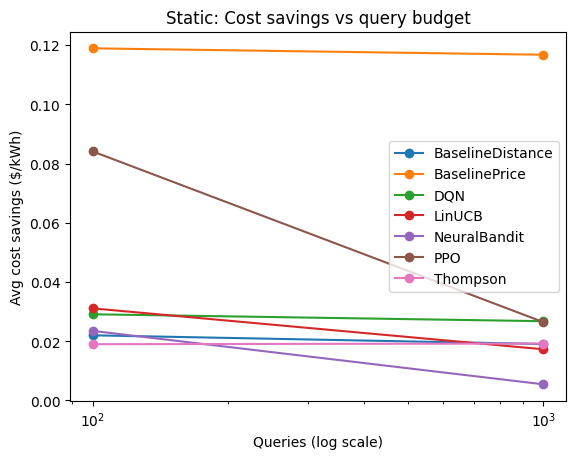

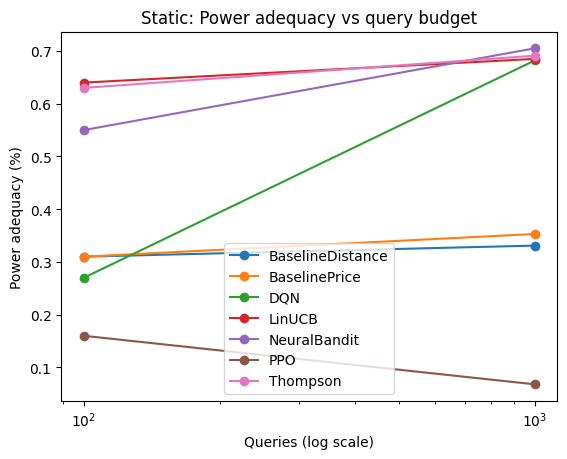

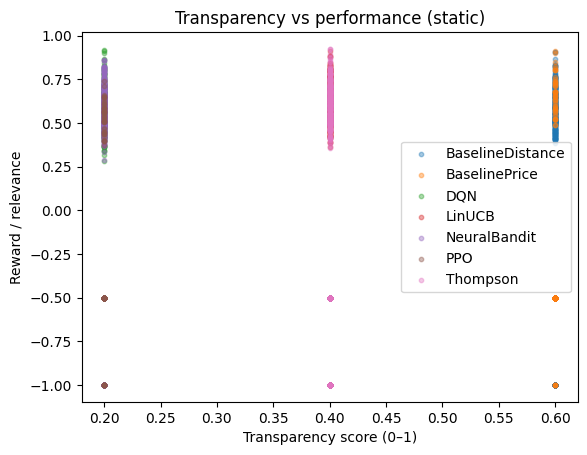

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_static_cost_savings(table1_long, outdir=None):
    plt.figure()
    for algo in sorted(table1_long["Algorithm"].unique()):
        df = table1_long[table1_long["Algorithm"] == algo].sort_values("Queries")
        plt.plot(df["Queries"], df["Avg cost savings"], marker="o", label=algo)
    plt.xscale("log")
    plt.xlabel("Queries (log scale)")
    plt.ylabel("Avg cost savings ($/kWh)")
    plt.title("Static: Cost savings vs query budget")
    plt.legend()
    if outdir: plt.savefig(f"{outdir}/static_cost_savings.png", dpi=200, bbox_inches="tight")
    plt.show()

def plot_static_power_adequacy(table1_long, outdir=None):
    plt.figure()
    for algo in sorted(table1_long["Algorithm"].unique()):
        df = table1_long[table1_long["Algorithm"] == algo].sort_values("Queries")
        plt.plot(df["Queries"], df["Power adequacy %"], marker="o", label=algo)
    plt.xscale("log")
    plt.xlabel("Queries (log scale)")
    plt.ylabel("Power adequacy (%)")
    plt.title("Static: Power adequacy vs query budget")
    plt.legend()
    if outdir: plt.savefig(f"{outdir}/static_power_adequacy.png", dpi=200, bbox_inches="tight")
    plt.show()

def plot_transparency_vs_reward(scatter_df, outdir=None):
    """
    scatter_df needs: Algorithm, transparency_score, reward
    Each row can be one query interaction.
    """
    plt.figure()
    for algo in sorted(scatter_df["Algorithm"].unique()):
        df = scatter_df[scatter_df["Algorithm"] == algo]
        plt.scatter(df["transparency_score"], df["reward"], s=10, alpha=0.4, label=algo)
    plt.xlabel("Transparency score (0–1)")
    plt.ylabel("Reward / relevance")
    plt.title("Transparency vs performance (static)")
    plt.legend()
    if outdir: plt.savefig(f"{outdir}/transparency_vs_reward.png", dpi=200, bbox_inches="tight")
    plt.show()

plot_static_cost_savings(table1_long)
plot_static_power_adequacy(table1_long)

# Create a simplified scatter_df for transparency vs reward plotting
scatter_df = static_logs.copy()
scatter_df = scatter_df.rename(columns={'reward': 'reward'})
plot_transparency_vs_reward(scatter_df)

Running dynamic benchmark with reduced parameters for quicker execution...
Loading Likitha Gedipudi dataset (Availability Tracking)...


100%|██████████| 22.7M/22.7M [00:00<00:00, 130MB/s] 

Extracting files...


✓ Loaded 1317750 time-series records from: ev_charging_station_data.csv
Dynamic benchmark complete. Generating plots...


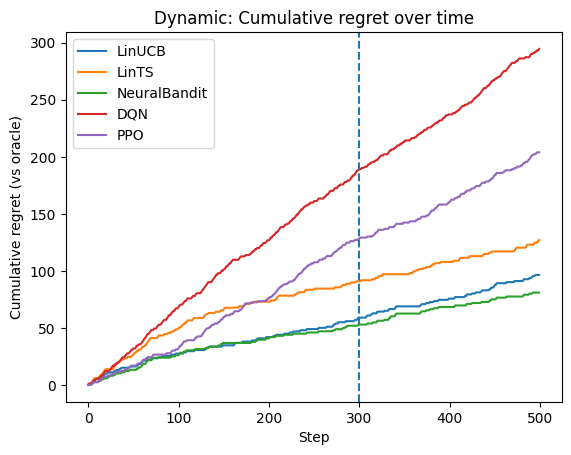

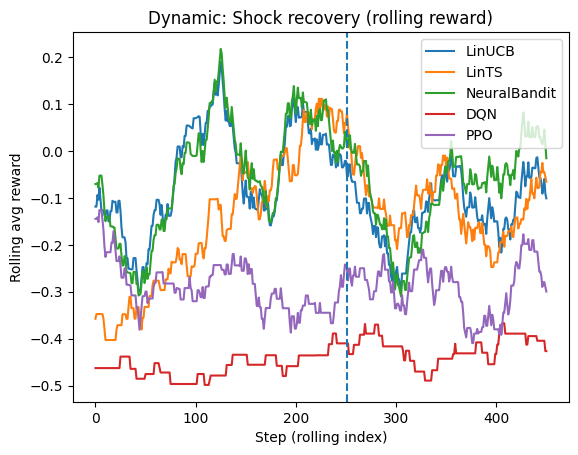


Dynamic Benchmark Results (table2_df):
   Algorithm  Steps  Avg price  Offline rate %  Regret vs oracle  Adaptation speed (steps)  Reward mean  Reward std  Constraint violation % Recovery time after shock (steps)
         DQN  500.0   0.298892            10.8        294.593171                     451.0    -0.445664    0.255290                    94.6                               152
       LinTS  500.0   0.298892            11.6        127.034928                     221.0    -0.147287    0.589040                    64.8                    >not recovered
      LinUCB  500.0   0.298892            10.8         96.445660                     125.0    -0.089617    0.624731                    59.0                               104
NeuralBandit  500.0   0.298892            11.4         80.948535                     125.0    -0.061623    0.628904                    55.6                               175
         PPO  500.0   0.298892            11.6        203.983774                     451.0

In [ ]:
import inspect, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def haversine_distance_vec(lat1, lon1, lat2, lon2):
    """Vectorized haversine distance in km."""
    R = 6371.0
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# ----------------------------
# Helper: rolling mean
# ----------------------------
def rolling_mean(x, w=50):
    x = np.asarray(x, dtype=float)
    if len(x) < w:
        return np.array([np.mean(x)]) if len(x) else np.array([0.0])
    return np.convolve(x, np.ones(w)/w, mode="valid")

# ----------------------------
# Helper: adaptation speed
# steps to reach 90% of best rolling reward
# ----------------------------
def adaptation_speed(reward_curve, window=50, threshold=0.90):
    rm = rolling_mean(reward_curve, w=window)
    best = float(np.max(rm)) if len(rm) else 0.0
    target = threshold * best
    for t, r in enumerate(rm):
        if r >= target:
            return t  # index in rolling series
    return len(rm)

# ----------------------------
# Helper: safe ChargingStation creation
# ----------------------------
def build_station_factory(ChargingStation):
    sig = inspect.signature(ChargingStation)
    valid_keys = set(sig.parameters.keys())

    def create_station_safe(row_dict):
        clean = {k: row_dict[k] for k in row_dict.keys() if k in valid_keys}
        return ChargingStation(**clean)
    return create_station_safe

# ----------------------------
# Regret vs oracle (per step)
# oracle = best feasible reward among candidates at this step
# ----------------------------
def regret_vs_oracle_step(chosen_reward, candidate_rewards, candidate_feasible):
    # oracle: max reward among feasible candidates; if none feasible, oracle = chosen reward
    feasible_rewards = [r for r, f in zip(candidate_rewards, candidate_feasible) if f]
    oracle = max(feasible_rewards) if feasible_rewards else chosen_reward
    return max(0.0, oracle - chosen_reward)

# ----------------------------
# Dynamic benchmark with shock + metrics
# ----------------------------
def run_dynamic_benchmark(
    static_df,
    dynamic_df,
    ChargingStation,
    Query,
    feature_builder,
    reward_fn,
    algorithms,               # dict: {"PPO": lambda: PPO(d), ...}
    steps=2000,
    candidate_k=30,
    shock_step=1500,
    shock_price_mult=1.5,
    shock_outage_frac=0.2,    # fraction of candidate stations forced offline at shock
    n_seeds=3,
    rolling_window=50
):
    """
    Returns:
      table2_df: summary per algo (mean over seeds)
      curves: dict with per-algo time series (reward, regret, etc.)
    """
    # --- Basic sanity required columns in static_df ---
    required_cols = ["latitude", "longitude", "max_power_kw", "cost_per_kwh_usd", "status"]
    for c in required_cols:
        if c not in static_df.columns:
            raise ValueError(f"static_df missing required column: {c}")

    # dynamic_df minimal expectation
    # columns often: current_price, station_status (operational/offline)
    if "current_price" not in dynamic_df.columns:
        dynamic_df = dynamic_df.copy()
        dynamic_df["current_price"] = 0.25
    if "station_status" not in dynamic_df.columns:
        dynamic_df = dynamic_df.copy()
        dynamic_df["station_status"] = "operational"

    create_station_safe = build_station_factory(ChargingStation)

    # storage
    curves = {name: {"reward": [], "regret": [], "offline": [], "viol": [], "price": []} for name in algorithms.keys()}
    summary_rows = []

    for algo_name, algo_factory in algorithms.items():
        # aggregate across seeds
        seed_summaries = []
        seed_reward_curves = []
        seed_regret_curves = []
        seed_offline_curves = []
        seed_viol_curves = []
        seed_price_curves = []

        for seed in range(n_seeds):
            np.random.seed(seed)

            policy = algo_factory()
            df_work = static_df.copy()

            rewards_list = []
            regret_list = []
            offline_list = []
            viol_list = []
            price_list = []

            pre_shock_roll = None
            recovery_steps = None

            for t in range(steps):
                # ---- Shock apply (price spike + outages) ----
                shock_now = (t == shock_step)
                if shock_now:
                    # record pre-shock performance (rolling mean of last window)
                    if len(rewards_list) >= rolling_window:
                        pre_shock_roll = float(np.mean(rewards_list[-rolling_window:]))
                    else:
                        pre_shock_roll = float(np.mean(rewards_list)) if rewards_list else 0.0

                # ---- Sample a query near a random station ----
                idx = np.random.randint(len(df_work))
                base = df_work.iloc[idx]

                query = Query(
                    query_id=f"dyn_{algo_name}_{seed}_{t}",
                    user_latitude=float(base["latitude"]) + np.random.randn() * 0.03,
                    user_longitude=float(base["longitude"]) + np.random.randn() * 0.03,
                    min_power_kw=float(np.random.choice([50, 100, 150])),
                    max_distance_km=15.0,
                )

                # ---- Candidate set: Select nearest stations (FIXED) ----
                dists = haversine_distance_vec(
                    query.user_latitude, query.user_longitude,
                    df_work["latitude"].values, df_work["longitude"].values
                )
                near_idx = np.argpartition(dists, candidate_k)[:candidate_k]
                cand_df = df_work.iloc[near_idx].copy()
                cand_df["dist_km"] = dists[near_idx]

                # ---- Dynamic record (loop if shorter) ----
                dyn = dynamic_df.iloc[t % len(dynamic_df)]
                dyn_price = float(dyn.get("current_price", 0.25))
                dyn_status_global = str(dyn.get("station_status", "operational")).lower()

                # apply shock to price
                if t >= shock_step:
                    dyn_price *= shock_price_mult

                # create station objects
                stations = [create_station_safe(row.to_dict()) for _, row in cand_df.iterrows()]

                # optionally force outages on a fraction at and after shock
                # we implement outage by overriding status at reward-time for some candidates
                outage_mask = np.zeros(len(stations), dtype=bool)
                if t >= shock_step and shock_outage_frac > 0:
                    m = int(shock_outage_frac * len(stations))
                    if m > 0:
                        outage_idx = np.random.choice(len(stations), m, replace=False)
                        outage_mask[outage_idx] = True

                # ---- Feature building ----
                # Adjust here if your build() signature differs
                try:
                    X = np.array([feature_builder.build(query, s, dyn_price) for s in stations], dtype=float)
                except TypeError:
                    X = np.array([feature_builder.build(query, s) for s in stations], dtype=float)

                # ---- Policy select ----
                a = policy.select(X, list(range(len(stations))))
                if a < 0 or a >= len(stations):
                    # fallback if policy returns invalid
                    a = int(np.random.randint(len(stations)))

                chosen = stations[a]

                # ---- Compute rewards for all candidates to get oracle (for regret) ----
                candidate_rewards = []
                candidate_feasible = []
                for i, st in enumerate(stations):
                    # station status override: either global dynamic status or forced outage
                    st_status = "offline" if outage_mask[i] else dyn_status_global
                    # Adjust here if your reward_fn.compute signature differs
                    r_i, feasible_i, _ = reward_fn.compute(query, st, price=dyn_price, status=st_status)
                    candidate_rewards.append(float(r_i))
                    candidate_feasible.append(bool(feasible_i))

                # chosen station status and reward
                chosen_status = "offline" if outage_mask[a] else dyn_status_global
                r, feasible, _ = reward_fn.compute(query, chosen, price=dyn_price, status=chosen_status)

                # ---- Update policy ----
                # Adjust if your policy.update signature differs
                policy.update(X, a, float(r))

                # ---- Metrics per step ----
                rewards_list.append(float(r))
                regret_list.append(regret_vs_oracle_step(float(r), candidate_rewards, candidate_feasible))
                offline_list.append(1.0 if chosen_status == "offline" else 0.0)
                viol_list.append(0.0 if feasible else 1.0)
                price_list.append(dyn_price)

                # ---- Recovery time after shock (to 95% of pre-shock rolling avg) ----
                if pre_shock_roll is not None and recovery_steps is None and t > shock_step + rolling_window:
                    current_roll = float(np.mean(rewards_list[-rolling_window:]))
                    if current_roll >= 0.95 * pre_shock_roll:
                        recovery_steps = t - shock_step

            # aggregate seed results
            seed_reward_curves.append(rewards_list)
            seed_regret_curves.append(regret_list)
            seed_offline_curves.append(offline_list)
            seed_viol_curves.append(viol_list)
            seed_price_curves.append(price_list)

            seed_summaries.append({
                "Algorithm": algo_name,
                "Steps": steps,
                "Avg price": float(np.mean(price_list)),
                "Offline rate %": float(np.mean(offline_list) * 100.0),
                "Constraint violation %": float(np.mean(viol_list) * 100.0),
                "Reward mean": float(np.mean(rewards_list)),
                "Reward std": float(np.std(rewards_list)),
                "Regret vs oracle": float(np.sum(regret_list)),
                "Adaptation speed (steps)": int(adaptation_speed(rewards_list, window=rolling_window, threshold=0.90)),
                "Recovery time after shock (steps)": int(recovery_steps) if recovery_steps is not None else -1
            })

        # mean over seeds for table
        df_seed = pd.DataFrame(seed_summaries)
        row = df_seed.mean(numeric_only=True).to_dict()
        row["Algorithm"] = algo_name
        summary_rows.append(row)

        # save mean curves for plotting (mean over seeds)
        curves[algo_name]["reward"] = np.mean(np.array(seed_reward_curves), axis=0).tolist()
        curves[algo_name]["regret"] = np.cumsum(np.mean(np.array(seed_regret_curves), axis=0)).tolist()
        curves[algo_name]["offline"] = np.mean(np.array(seed_offline_curves), axis=0).tolist()
        curves[algo_name]["viol"] = np.mean(np.array(seed_viol_curves), axis=0).tolist()
        curves[algo_name]["price"] = np.mean(np.array(seed_price_curves), axis=0).tolist()

    table2_df = pd.DataFrame(summary_rows)

    # Make recovery time readable
    table2_df["Recovery time after shock (steps)"] = table2_df["Recovery time after shock (steps)"].apply(
        lambda x: ">not recovered" if int(x) < 0 else int(x)
    )

    # reorder columns cleanly
    cols = [
        "Algorithm", "Steps", "Avg price", "Offline rate %", "Regret vs oracle",
        "Adaptation speed (steps)", "Reward mean", "Reward std",
        "Constraint violation %", "Recovery time after shock (steps)"
    ]
    table2_df = table2_df[cols]

    return table2_df, curves

# ----------------------------
# Plot dynamic curves: regret + shock recovery
# ----------------------------
def plot_dynamic_curves(curves, shock_step, outdir=None):
    # Cumulative regret over time
    plt.figure()
    for algo, d in curves.items():
        plt.plot(d["regret"], label=algo)
    plt.axvline(shock_step, linestyle="--")
    plt.xlabel("Step")
    plt.ylabel("Cumulative regret (vs oracle)")
    plt.title("Dynamic: Cumulative regret over time")
    plt.legend()
    if outdir: plt.savefig(f"{outdir}/dynamic_cum_regret.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Shock recovery curve (rolling reward)
    plt.figure()
    for algo, d in curves.items():
        rm = rolling_mean(d["reward"], w=50)
        plt.plot(rm, label=algo)
    # shock line in rolling coordinates (shifted by window-1 in conv)
    plt.axvline(max(0, shock_step - 50 + 1), linestyle="--")
    plt.xlabel("Step (rolling index)")
    plt.ylabel("Rolling avg reward")
    plt.title("Dynamic: Shock recovery (rolling reward)")
    plt.legend()
    if outdir: plt.savefig(f"{outdir}/dynamic_shock_recovery.png", dpi=200, bbox_inches="tight")
    plt.show()

algorithms_dynamic = {
    "LinUCB": lambda: LinUCB(8),
    "LinTS": lambda: ThompsonSampling(8),
    "NeuralBandit": lambda: NeuralBandit(8, hidden_dim=32),
    "DQN": lambda: DQN(8),
    "PPO": lambda: PPO(8),
}

print("Running dynamic benchmark with reduced parameters for quicker execution...")

# Ensure dynamic_df is loaded. If it's not present in kernel state, load it.
# Based on kernel state, dynamic_df is not available as a variable. Assuming it needs to be loaded.
# Loading Likitha Gedipudi Dynamic Dataset
if 'dynamic_df' not in locals() or dynamic_df.empty:
    print("Loading Likitha Gedipudi dataset (Availability Tracking)...")
    try:
        dynamic_path = kagglehub.dataset_download("likithagedipudi/ev-charging-station-availability-tracking")
        csv_files_dynamic = [f for f in os.listdir(dynamic_path) if f.endswith('.csv')]
        if csv_files_dynamic:
            file_path_dynamic = os.path.join(dynamic_path, csv_files_dynamic[0])
            dynamic_df = pd.read_csv(file_path_dynamic)
            print(f"✓ Loaded {len(dynamic_df)} time-series records from: {csv_files_dynamic[0]}")
        else:
            raise FileNotFoundError("No CSV file found in the dynamic dataset directory.")
    except Exception as e:
        print(f"\n⚠️ Error loading Dynamic Dataset: {e}")
        dynamic_df = pd.DataFrame()

table2_df, dyn_curves = run_dynamic_benchmark(
    static_df=cleaned_df,
    dynamic_df=dynamic_df,
    ChargingStation=ChargingStation,
    Query=Query,
    feature_builder=feature_builder,
    reward_fn=reward_fn,
    algorithms=algorithms_dynamic,
    steps=500,
    shock_step=300, # Adjust shock step to be within the reduced steps
    n_seeds=1
)

print("Dynamic benchmark complete. Generating plots...")
plot_dynamic_curves(dyn_curves, shock_step=300)

print("\nDynamic Benchmark Results (table2_df):")
print(table2_df.sort_values("Algorithm").to_string(index=False))

Running dynamic benchmark with reduced parameters for quicker execution...
Dynamic benchmark complete. Generating plots...


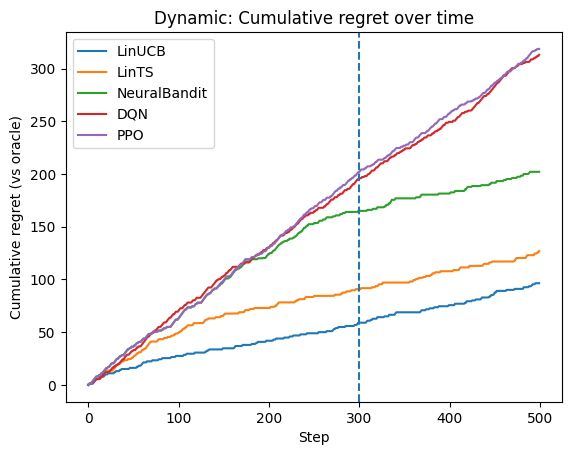

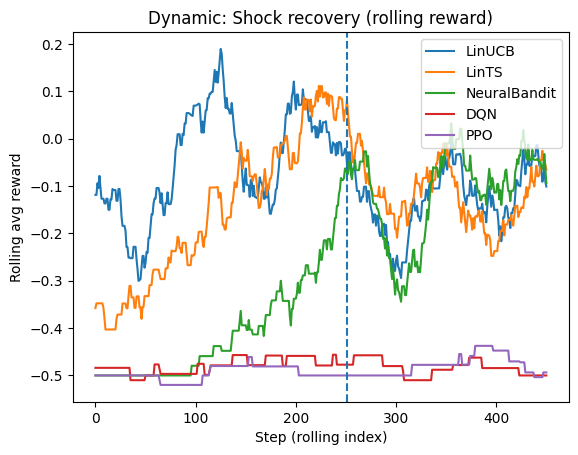


Dynamic Benchmark Results (table2_df):
   Algorithm  Steps  Avg price  Offline rate %  Regret vs oracle  Adaptation speed (steps)  Reward mean  Reward std  Constraint violation % Recovery time after shock (steps)
         DQN  500.0   0.298892            11.0        313.060109                     451.0    -0.482598    0.157890                    98.0                    >not recovered
       LinTS  500.0   0.298892            11.6        127.034928                     221.0    -0.147287    0.589040                    64.8                    >not recovered
      LinUCB  500.0   0.298892            10.8         96.445660                     125.0    -0.089617    0.624731                    59.0                               104
NeuralBandit  500.0   0.298892            12.6        202.089280                     355.0    -0.279904    0.500360                    76.0                                93
         PPO  500.0   0.298892            10.8        318.620049                     451.0

In [ ]:
import inspect, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def haversine_distance_vec(lat1, lon1, lat2, lon2):
    """Vectorized haversine distance in km."""
    R = 6371.0
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# ----------------------------
# Helper: rolling mean
# ----------------------------
def rolling_mean(x, w=50):
    x = np.asarray(x, dtype=float)
    if len(x) < w:
        return np.array([np.mean(x)]) if len(x) else np.array([0.0])
    return np.convolve(x, np.ones(w)/w, mode="valid")

# ----------------------------
# Helper: adaptation speed
# steps to reach 90% of best rolling reward
# ----------------------------
def adaptation_speed(reward_curve, window=50, threshold=0.90):
    rm = rolling_mean(reward_curve, w=window)
    best = float(np.max(rm)) if len(rm) else 0.0
    target = threshold * best
    for t, r in enumerate(rm):
        if r >= target:
            return t  # index in rolling series
    return len(rm)

# ----------------------------
# Helper: safe ChargingStation creation
# ----------------------------
def build_station_factory(ChargingStation):
    sig = inspect.signature(ChargingStation)
    valid_keys = set(sig.parameters.keys())

    def create_station_safe(row_dict):
        clean = {k: row_dict[k] for k in row_dict.keys() if k in valid_keys}
        return ChargingStation(**clean)
    return create_station_safe

# ----------------------------
# Regret vs oracle (per step)
# oracle = best feasible reward among candidates at this step
# ----------------------------
def regret_vs_oracle_step(chosen_reward, candidate_rewards, candidate_feasible):
    # oracle: max reward among feasible candidates; if none feasible, oracle = chosen reward
    feasible_rewards = [r for r, f in zip(candidate_rewards, candidate_feasible) if f]
    oracle = max(feasible_rewards) if feasible_rewards else chosen_reward
    return max(0.0, oracle - chosen_reward)

# ----------------------------
# Dynamic benchmark with shock + metrics
# ----------------------------
def run_dynamic_benchmark(
    static_df,
    dynamic_df,
    ChargingStation,
    Query,
    feature_builder,
    reward_fn,
    algorithms,               # dict: {"PPO": lambda: PPO(d), ...}
    steps=2000,
    candidate_k=30,
    shock_step=1500,
    shock_price_mult=1.5,
    shock_outage_frac=0.2,    # fraction of candidate stations forced offline at shock
    n_seeds=3,
    rolling_window=50
):
    """
    Returns:
      table2_df: summary per algo (mean over seeds)
      curves: dict with per-algo time series (reward, regret, etc.)
    """
    # --- Basic sanity required columns in static_df ---
    required_cols = ["latitude", "longitude", "max_power_kw", "cost_per_kwh_usd", "status"]
    for c in required_cols:
        if c not in static_df.columns:
            raise ValueError(f"static_df missing required column: {c}")

    # dynamic_df minimal expectation
    # columns often: current_price, station_status (operational/offline)
    if "current_price" not in dynamic_df.columns:
        dynamic_df = dynamic_df.copy()
        dynamic_df["current_price"] = 0.25
    if "station_status" not in dynamic_df.columns:
        dynamic_df = dynamic_df.copy()
        dynamic_df["station_status"] = "operational"

    create_station_safe = build_station_factory(ChargingStation)

    # storage
    curves = {name: {"reward": [], "regret": [], "offline": [], "viol": [], "price": []} for name in algorithms.keys()}
    summary_rows = []

    for algo_name, algo_factory in algorithms.items():
        # aggregate across seeds
        seed_summaries = []
        seed_reward_curves = []
        seed_regret_curves = []
        seed_offline_curves = []
        seed_viol_curves = []
        seed_price_curves = []

        for seed in range(n_seeds):
            np.random.seed(seed)

            policy = algo_factory()
            df_work = static_df.copy()

            rewards_list = []
            regret_list = []
            offline_list = []
            viol_list = []
            price_list = []

            pre_shock_roll = None
            recovery_steps = None

            for t in range(steps):
                # ---- Shock apply (price spike + outages) ----
                shock_now = (t == shock_step)
                if shock_now:
                    # record pre-shock performance (rolling mean of last window)
                    if len(rewards_list) >= rolling_window:
                        pre_shock_roll = float(np.mean(rewards_list[-rolling_window:]))
                    else:
                        pre_shock_roll = float(np.mean(rewards_list)) if rewards_list else 0.0

                # ---- Sample a query near a random station ----
                idx = np.random.randint(len(df_work))
                base = df_work.iloc[idx]

                query = Query(
                    query_id=f"dyn_{algo_name}_{seed}_{t}",
                    user_latitude=float(base["latitude"]) + np.random.randn() * 0.03,
                    user_longitude=float(base["longitude"]) + np.random.randn() * 0.03,
                    min_power_kw=float(np.random.choice([50, 100, 150])),
                    max_distance_km=15.0,
                )

                # ---- Candidate set: Select nearest stations (FIXED) ----
                dists = haversine_distance_vec(
                    query.user_latitude, query.user_longitude,
                    df_work["latitude"].values, df_work["longitude"].values
                )
                near_idx = np.argpartition(dists, candidate_k)[:candidate_k]
                cand_df = df_work.iloc[near_idx].copy()
                cand_df["dist_km"] = dists[near_idx]

                # ---- Dynamic record (loop if shorter) ----
                dyn = dynamic_df.iloc[t % len(dynamic_df)]
                dyn_price = float(dyn.get("current_price", 0.25))
                dyn_status_global = str(dyn.get("station_status", "operational")).lower()

                # apply shock to price
                if t >= shock_step:
                    dyn_price *= shock_price_mult

                # create station objects
                stations = [create_station_safe(row.to_dict()) for _, row in cand_df.iterrows()]

                # optionally force outages on a fraction at and after shock
                # we implement outage by overriding status at reward-time for some candidates
                outage_mask = np.zeros(len(stations), dtype=bool)
                if t >= shock_step and shock_outage_frac > 0:
                    m = int(shock_outage_frac * len(stations))
                    if m > 0:
                        outage_idx = np.random.choice(len(stations), m, replace=False)
                        outage_mask[outage_idx] = True

                # ---- Feature building ----
                # Adjust here if your build() signature differs
                try:
                    X = np.array([feature_builder.build(query, s, dyn_price) for s in stations], dtype=float)
                except TypeError:
                    X = np.array([feature_builder.build(query, s) for s in stations], dtype=float)

                # ---- Policy select ----
                a = policy.select(X, list(range(len(stations))))
                if a < 0 or a >= len(stations):
                    # fallback if policy returns invalid
                    a = int(np.random.randint(len(stations)))

                chosen = stations[a]

                # ---- Compute rewards for all candidates to get oracle (for regret) ----
                candidate_rewards = []
                candidate_feasible = []
                for i, st in enumerate(stations):
                    # station status override: either global dynamic status or forced outage
                    st_status = "offline" if outage_mask[i] else dyn_status_global
                    # Adjust here if your reward_fn.compute signature differs
                    r_i, feasible_i, _ = reward_fn.compute(query, st, price=dyn_price, status=st_status)
                    candidate_rewards.append(float(r_i))
                    candidate_feasible.append(bool(feasible_i))

                # chosen station status and reward
                chosen_status = "offline" if outage_mask[a] else dyn_status_global
                r, feasible, _ = reward_fn.compute(query, chosen, price=dyn_price, status=chosen_status)

                # ---- Update policy ----
                # Adjust if your policy.update signature differs
                policy.update(X, a, float(r))

                # ---- Metrics per step ----
                rewards_list.append(float(r))
                regret_list.append(regret_vs_oracle_step(float(r), candidate_rewards, candidate_feasible))
                offline_list.append(1.0 if chosen_status == "offline" else 0.0)
                viol_list.append(0.0 if feasible else 1.0)
                price_list.append(dyn_price)

                # ---- Recovery time after shock (to 95% of pre-shock rolling avg) ----
                if pre_shock_roll is not None and recovery_steps is None and t > shock_step + rolling_window:
                    current_roll = float(np.mean(rewards_list[-rolling_window:]))
                    if current_roll >= 0.95 * pre_shock_roll:
                        recovery_steps = t - shock_step

            # aggregate seed results
            seed_reward_curves.append(rewards_list)
            seed_regret_curves.append(regret_list)
            seed_offline_curves.append(offline_list)
            seed_viol_curves.append(viol_list)
            seed_price_curves.append(price_list)

            seed_summaries.append({
                "Algorithm": algo_name,
                "Steps": steps,
                "Avg price": float(np.mean(price_list)),
                "Offline rate %": float(np.mean(offline_list) * 100.0),
                "Constraint violation %": float(np.mean(viol_list) * 100.0),
                "Reward mean": float(np.mean(rewards_list)),
                "Reward std": float(np.std(rewards_list)),
                "Regret vs oracle": float(np.sum(regret_list)),
                "Adaptation speed (steps)": int(adaptation_speed(rewards_list, window=rolling_window, threshold=0.90)),
                "Recovery time after shock (steps)": int(recovery_steps) if recovery_steps is not None else -1
            })

        # mean over seeds for table
        df_seed = pd.DataFrame(seed_summaries)
        row = df_seed.mean(numeric_only=True).to_dict()
        row["Algorithm"] = algo_name
        summary_rows.append(row)

        # save mean curves for plotting (mean over seeds)
        curves[algo_name]["reward"] = np.mean(np.array(seed_reward_curves), axis=0).tolist()
        curves[algo_name]["regret"] = np.cumsum(np.mean(np.array(seed_regret_curves), axis=0)).tolist()
        curves[algo_name]["offline"] = np.mean(np.array(seed_offline_curves), axis=0).tolist()
        curves[algo_name]["viol"] = np.mean(np.array(seed_viol_curves), axis=0).tolist()
        curves[algo_name]["price"] = np.mean(np.array(seed_price_curves), axis=0).tolist()

    table2_df = pd.DataFrame(summary_rows)

    # Make recovery time readable
    table2_df["Recovery time after shock (steps)"] = table2_df["Recovery time after shock (steps)"].apply(
        lambda x: ">not recovered" if int(x) < 0 else int(x)
    )

    # reorder columns cleanly
    cols = [
        "Algorithm", "Steps", "Avg price", "Offline rate %", "Regret vs oracle",
        "Adaptation speed (steps)", "Reward mean", "Reward std",
        "Constraint violation %", "Recovery time after shock (steps)"
    ]
    table2_df = table2_df[cols]

    return table2_df, curves

# ----------------------------
# Plot dynamic curves: regret + shock recovery
# ----------------------------
def plot_dynamic_curves(curves, shock_step, outdir=None):
    # Cumulative regret over time
    plt.figure()
    for algo, d in curves.items():
        plt.plot(d["regret"], label=algo)
    plt.axvline(shock_step, linestyle="--")
    plt.xlabel("Step")
    plt.ylabel("Cumulative regret (vs oracle)")
    plt.title("Dynamic: Cumulative regret over time")
    plt.legend()
    if outdir: plt.savefig(f"{outdir}/dynamic_cum_regret.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Shock recovery curve (rolling reward)
    plt.figure()
    for algo, d in curves.items():
        rm = rolling_mean(d["reward"], w=50)
        plt.plot(rm, label=algo)
    # shock line in rolling coordinates (shifted by window-1 in conv)
    plt.axvline(max(0, shock_step - 50 + 1), linestyle="--")
    plt.xlabel("Step (rolling index)")
    plt.ylabel("Rolling avg reward")
    plt.title("Dynamic: Shock recovery (rolling reward)")
    plt.legend()
    if outdir: plt.savefig(f"{outdir}/dynamic_shock_recovery.png", dpi=200, bbox_inches="tight")
    plt.show()

algorithms_dynamic = {
    "LinUCB": lambda: LinUCB(8),
    "LinTS": lambda: ThompsonSampling(8),
    "NeuralBandit": lambda: NeuralBandit(8, hidden_dim=32),
    "DQN": lambda: DQN(8),
    "PPO": lambda: PPO(8),
}

print("Running dynamic benchmark with reduced parameters for quicker execution...")

# Ensure dynamic_df is loaded. If it's not present in kernel state, load it.
# Based on kernel state, dynamic_df is not available as a variable. Assuming it needs to be loaded.
# Loading Likitha Gedipudi Dynamic Dataset
if 'dynamic_df' not in locals() or dynamic_df.empty:
    print("Loading Likitha Gedipudi dataset (Availability Tracking)...")
    try:
        dynamic_path = kagglehub.dataset_download("likithagedipudi/ev-charging-station-availability-tracking")
        csv_files_dynamic = [f for f in os.listdir(dynamic_path) if f.endswith('.csv')]
        if csv_files_dynamic:
            file_path_dynamic = os.path.join(dynamic_path, csv_files_dynamic[0])
            dynamic_df = pd.read_csv(file_path_dynamic)
            print(f"✓ Loaded {len(dynamic_df)} time-series records from: {csv_files_dynamic[0]}")
        else:
            raise FileNotFoundError("No CSV file found in the dynamic dataset directory.")
    except Exception as e:
        print(f"\n⚠️ Error loading Dynamic Dataset: {e}")
        dynamic_df = pd.DataFrame()

table2_df, dyn_curves = run_dynamic_benchmark(
    static_df=cleaned_df,
    dynamic_df=dynamic_df,
    ChargingStation=ChargingStation,
    Query=Query,
    feature_builder=feature_builder,
    reward_fn=reward_fn,
    algorithms=algorithms_dynamic,
    steps=500,
    shock_step=300, # Adjust shock step to be within the reduced steps
    n_seeds=1
)

print("Dynamic benchmark complete. Generating plots...")
plot_dynamic_curves(dyn_curves, shock_step=300)

print("\nDynamic Benchmark Results (table2_df):")
print(table2_df.sort_values("Algorithm").to_string(index=False))
